<a href="https://colab.research.google.com/github/sxfchen/smc/blob/main/smc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import libraries and preprocess data

In [1]:
# !pip install visualkeras

In [2]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
import tensorflow_hub as hub
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, BatchNormalization, Dropout, Activation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
# import visualkeras
from tensorflow.keras.utils import plot_model

from tqdm import tqdm
from skimage.segmentation import quickshift
from skimage.color import rgb2gray
from scipy.ndimage import gaussian_filter
from scipy.special import comb
from skimage.segmentation import slic
from collections import Counter

from scipy import stats
from sklearn.metrics import ndcg_score

In [3]:
!wget https://www.dropbox.com/scl/fi/7l0ny5wtvvo9cr8n1ivxm/braintumor.zip?rlkey=cjv5cmpxjcc2cco03ysffyw4p&st=9tqq8xf9&dl=0

--2024-12-10 00:11:36--  https://www.dropbox.com/scl/fi/7l0ny5wtvvo9cr8n1ivxm/braintumor.zip?rlkey=cjv5cmpxjcc2cco03ysffyw4p
Resolving www.dropbox.com (www.dropbox.com)... 162.125.2.18, 2620:100:6021:18::a27d:4112
Connecting to www.dropbox.com (www.dropbox.com)|162.125.2.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucfc947a993decd52830967d37ea.dl.dropboxusercontent.com/cd/0/inline/Cf9_TfijPO8Ogei79sqSM68nbKlktIzqDlUkKKexwpzjvce25ysrDU_smnCwgv489G_kr3W0-PDpwvljY5VFaUqsZkq5l89mePAGYv7gHRUam-brb73iJ8bwveKPGr0KtLp5qjt7lCjI4Kj8ttEbz0-N/file# [following]
--2024-12-10 00:11:36--  https://ucfc947a993decd52830967d37ea.dl.dropboxusercontent.com/cd/0/inline/Cf9_TfijPO8Ogei79sqSM68nbKlktIzqDlUkKKexwpzjvce25ysrDU_smnCwgv489G_kr3W0-PDpwvljY5VFaUqsZkq5l89mePAGYv7gHRUam-brb73iJ8bwveKPGr0KtLp5qjt7lCjI4Kj8ttEbz0-N/file
Resolving ucfc947a993decd52830967d37ea.dl.dropboxusercontent.com (ucfc947a993decd52830967d37ea.dl.dropboxusercontent.com)... 162.125.2.15, 262

In [4]:
file_path = ('/content/braintumor.zip?rlkey=cjv5cmpxjcc2cco03ysffyw4p')
extraction_path = '/content/data'

if not os.path.exists(extraction_path):
    os.makedirs(extraction_path)

with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f'Files extracted to {extraction_path}')

Files extracted to /content/data


In [5]:
train_path = '/content/data/Training'
test_path = '/content/data/Testing'
target_size = (128, 128)

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=target_size,
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=target_size,
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=True
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=target_size,
    color_mode='rgb',
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

train_image_paths = [os.path.join(train_path, fname) for fname in train_generator.filenames]
train_labels = train_generator.classes

val_image_paths = [os.path.join(train_path, fname) for fname in validation_generator.filenames]
val_labels = validation_generator.classes

test_image_paths = [os.path.join(test_path, fname) for fname in test_generator.filenames]
test_labels = test_generator.classes

train_df = pd.DataFrame({
    'Image': train_image_paths,
    'Class': train_labels
})

val_df = pd.DataFrame({
    'Image': val_image_paths,
    'Class': val_labels
})

test_df = pd.DataFrame({
    'Image': test_image_paths,
    'Class': test_labels
})

print(train_df.head())

Found 4571 images belonging to 4 classes.
Found 1141 images belonging to 4 classes.
Found 1311 images belonging to 4 classes.
                                          Image  Class
0  /content/data/Training/glioma/Tr-gl_0264.jpg      0
1  /content/data/Training/glioma/Tr-gl_0265.jpg      0
2  /content/data/Training/glioma/Tr-gl_0266.jpg      0
3  /content/data/Training/glioma/Tr-gl_0267.jpg      0
4  /content/data/Training/glioma/Tr-gl_0268.jpg      0


# Train model

In [6]:
keras.backend.clear_session()

img_shape = (128, 128, 3)

base_model = tf.keras.applications.EfficientNetV2S(include_top=False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

model = models.Sequential([
    base_model,
    Flatten(),
    Dropout(0.25, seed=42),
    Dense(128, activation=None),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3, seed=42),
    Dense(4, activation='softmax')
])

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [7]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)

model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [9]:
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta = 0.0001,
    verbose=1,
    restore_best_weights=True  # Restores model weights from the epoch with the best value of the monitored quantity
)

lr_scheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, min_lr = 0.000001, patience=4, verbose=1)

history = model.fit(
    train_generator,
    epochs=30,
    batch_size=32,
    validation_data=validation_generator,
    callbacks=[early_stopping, lr_scheduler]
)

Epoch 1/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 289ms/step - accuracy: 0.9673 - loss: 0.0991 - val_accuracy: 0.9220 - val_loss: 0.2263 - learning_rate: 5.0000e-04
Epoch 2/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 78s 261ms/step - accuracy: 0.9772 - loss: 0.0724 - val_accuracy: 0.7572 - val_loss: 0.7295 - learning_rate: 5.0000e-04
Epoch 3/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 38s 261ms/step - accuracy: 0.9790 - loss: 0.0666 - val_accuracy: 0.3655 - val_loss: 2.7968 - learning_rate: 5.0000e-04
Epoch 4/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 41s 260ms/step - accuracy: 0.9881 - loss: 0.0368 - val_accuracy: 0.9229 - val_loss: 0.2476 - learning_rate: 5.0000e-04
Epoch 5/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step - accuracy: 0.9844 - loss: 0.0484
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
143/143 ━━━━━━━━━━━━━━━━━━━━ 40s 252ms/step - accuracy: 0.9844 - loss: 0.0484 - val_accuracy: 0.9387 - val_loss: 0.2577 - learning_rate: 5.0000e-04
Epoch 6/30
143/143 ━━━━━━━━━━━━━━━━━━━━ 42s 261ms/st

In [10]:
loss, accuracy = model.evaluate(test_generator)

41/41 ━━━━━━━━━━━━━━━━━━━━ 10s 257ms/step - accuracy: 0.9613 - loss: 0.1163


In [ ]:
# plot_model(model, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)
# data subgenerators by class are in the attribution examples notebook

# Interpretability

Define functions
---



In [12]:
# Plotting ablation
# single
def plot_ablation_result(results, title="Ablation Analysis Results"):
    percentages = sorted(results.keys())
    accuracies = [results[p]['accuracy'] for p in percentages]

    plt.figure(figsize=(10, 6))
    plt.plot(percentages, accuracies, marker='o', color='tab:blue')
    plt.xlabel("Percentage of Features Ablated")
    plt.ylabel("Accuracy")
    plt.title(title)

    for x, y in zip(percentages, accuracies):
        plt.text(x, y, f'{y:.2f}', ha='center', va='bottom')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

# multiple
def plot_ablation_results(results, results2, results3, results4, title="Comparison of Ablation Analysis Results",
                          label1="Saliency maps", label2="Guided backpropagation", label3="Integrated gradients",label4="RISE"):
    results = [results, results2, results3, results4]
    labels = [label1, label2, label3, label4]
    colors = ['tab:blue','tab:green', 'tab:red', 'tab:orange']
    markers = ['o', 'o', 'o','o']

    plt.figure(figsize=(14, 8))

    for i, (result, label, color, marker) in enumerate(zip(results, labels, colors, markers)):
        percentages = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90]
        accuracies = [result[p]['accuracy'] for p in percentages]

        plt.plot(percentages, accuracies, marker=marker, color=color, label=label)

        # Add value labels for accuracy
        for x, y in zip(percentages, accuracies):
            plt.text(x, y, f'{y:.2f}', ha='center', va='bottom' if i % 2 == 0 else 'top', color=color)

    plt.xlabel("Percentage of Features Ablated")
    plt.ylabel("Accuracy")
    plt.title(title)

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()

In [13]:
# Method 1: RISE

@tf.function(experimental_relax_shapes=True)
def predict_batch(model, batch):
    return model(batch, training=False)

def generate_masks(input_size, mask_size, num_masks):
    cell_size = np.ceil(np.array(input_size) / mask_size)
    up_size = (np.ceil(np.array(input_size) / cell_size) * cell_size).astype(int)
    masks = np.random.rand(num_masks, mask_size, mask_size) < 0.5
    masks = np.repeat(np.repeat(masks, cell_size[0], axis=1), cell_size[1], axis=2)
    masks = masks[:, :input_size[0], :input_size[1]]
    return tf.constant(masks, dtype=tf.float32)

@tf.function(experimental_relax_shapes=True)
def apply_masks(image, masks):
    image = tf.expand_dims(image, 0)
    masks = tf.expand_dims(masks, -1)
    masked_images = image * masks
    return masked_images

@tf.function(experimental_relax_shapes=True)
def calculate_importance_rise(model, image, masks):
    masked_images = apply_masks(image, masks)
    predictions = predict_batch(model, masked_images)
    predictions_reshaped = tf.reshape(predictions, [-1, 1, 1, tf.shape(predictions)[-1]])
    importance_map = tf.reduce_sum(predictions_reshaped * tf.expand_dims(masks, -1), axis=0)
    return importance_map


def pixel_level_importance_rise_batch(model, batch, masks):
    return tf.map_fn(
        lambda x: calculate_importance_rise(model, x, masks),
        batch,
        fn_output_signature=tf.TensorSpec(shape=(None, None, None), dtype=tf.float32)
    )

@tf.function(experimental_relax_shapes=True)
def rank_features_batch(importance_maps):
    return tf.argsort(tf.reshape(importance_maps, [tf.shape(importance_maps)[0], -1]), axis=1, direction='DESCENDING')

@tf.function(experimental_relax_shapes=True)
def ablate_batch_rise(batch, ranked_features, num_features_to_remove):
    batch_size = tf.shape(batch)[0]
    height = tf.shape(batch)[1]
    width = tf.shape(batch)[2]
    ablated_batch = tf.identity(batch)

    # Create a mask for ablation
    mask = tf.ones_like(ablated_batch)

    # Create indices for all features to remove
    batch_indices = tf.repeat(tf.range(batch_size), num_features_to_remove)
    feature_indices = tf.reshape(ranked_features[:, :num_features_to_remove], [-1])

    # Calculate rows and cols without using tf.unravel_index
    rows = feature_indices // width
    cols = feature_indices % width

    indices = tf.stack([batch_indices, rows, cols], axis=1)

    # Set the mask values to 0 for the features to remove
    updates = tf.zeros([batch_size * num_features_to_remove, tf.shape(batch)[-1]], dtype=tf.float32)
    mask = tf.tensor_scatter_nd_update(mask, indices, updates)

    # Apply the mask to the batch
    ablated_batch *= mask

    return ablated_batch


def ablate_and_evaluate_batch_rise(model, generator, num_batches, percentages, masks):
    accuracies = {p: [] for p in percentages}
    confidences = {p: [] for p in percentages}
    class_predictions = {p: [] for p in percentages}

    for _ in tqdm(range(num_batches)):
        batch, labels = next(generator)
        importance_maps = pixel_level_importance_rise_batch(model, batch, masks)
        ranked_features_batch = rank_features_batch(importance_maps)

        for percentage in percentages:
            num_features_to_remove = tf.cast(tf.cast(tf.shape(batch)[1] * tf.shape(batch)[2], tf.float32) * (percentage / 100), tf.int32)
            ablated_batch = ablate_batch_rise(batch, ranked_features_batch, num_features_to_remove)

            predictions = predict_batch(model, ablated_batch)
            predicted_classes = tf.argmax(predictions, axis=1)
            correct = tf.equal(predicted_classes, tf.argmax(labels, axis=1))

            accuracies[percentage].extend(correct.numpy())
            confidences[percentage].extend(tf.reduce_max(predictions, axis=1).numpy())
            class_predictions[percentage].extend(predicted_classes.numpy())

    results = {}
    for p in percentages:
        results[p] = {
            'accuracy': np.mean(accuracies[p]),
            'class_distribution': dict(zip(*np.unique(class_predictions[p], return_counts=True))),
            'mean_confidence': np.mean(confidences[p])
        }

    return results

def run_rise_analysis(model, generator, input_size=(128, 128), mask_size=10, num_masks=2000, num_batches=10, percentages=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90]):
    masks = generate_masks(input_size, mask_size, num_masks)
    results = ablate_and_evaluate_batch_rise(model, generator, num_batches, percentages, masks)
    return results

def plot_importance_map_histograms(importance_map):
    importance_map_np = importance_map.numpy()

    # Check if the shape is as expected
    if importance_map_np.shape[-1] != 4:
        raise ValueError("Importance map does not have 4 channels as expected.")

    # Flatten the importance map for each channel
    importance_map_flat = [importance_map_np[:, :, i].flatten() for i in range(4)]

    # Plot histograms for each channel
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    for i, ax in enumerate(axes):
        ax.hist(importance_map_flat[i], bins=50, range=(np.min(importance_map_np), np.max(importance_map_np)), alpha=0.7)
        ax.set_title(f'Channel {i}')
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')

    plt.tight_layout()
    plt.show()

In [14]:
# Method 2: integrated gradients

def normalize_ig(ig):
    return (ig - tf.reduce_min(ig)) / (tf.reduce_max(ig) - tf.reduce_min(ig) + 1e-7)

@tf.function
def integrated_gradients_step_vectorized(model, interpolated_images, label):
    with tf.GradientTape() as tape:
        tape.watch(interpolated_images)
        predictions = model(interpolated_images, training=False)
        loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(
            tf.repeat(tf.expand_dims(label, 0), repeats=tf.shape(interpolated_images)[0], axis=0),
            predictions
        ))
    return tape.gradient(loss, interpolated_images)

def integrated_gradients_for_classification(model, generator, num_samples=100, steps=50):
    zero_baseline = tf.zeros_like(next(generator)[0][0])  # Change to zero baseline
    alphas = tf.pow(tf.linspace(0.0, 1.0, steps), 2)  # Quadratic interpolation

    results = []

    for _ in tqdm(range(num_samples)):
        image, label = next(generator)
        image = tf.convert_to_tensor(image[0])
        label = tf.convert_to_tensor(label[0])

        interpolated_images = tf.expand_dims(zero_baseline, 0) + alphas[:, tf.newaxis, tf.newaxis, tf.newaxis] * (image - zero_baseline)
        gradients = integrated_gradients_step_vectorized(model, interpolated_images, label)

        integrated_gradients = (image - zero_baseline) * tf.reduce_mean(gradients, axis=0)
        normalized_ig = normalize_ig(integrated_gradients)
        results.append(normalized_ig)

    return results

@tf.function
def predict_batch(model, images):
    return model(images, training=False)

def ablate_and_evaluate_ig(model, generator, ranked_features, percentages, zero_baseline, num_samples=100, batch_size=32):
    image_size = 128 * 128 * 3  # Total number of features in each image
    results = {p: {'correct': 0, 'total': 0, 'confidences': [], 'class_predictions': []} for p in percentages}

    for _ in tqdm(range(num_samples // batch_size)):
        images, labels = next(generator)
        images = tf.convert_to_tensor(images)
        labels = tf.convert_to_tensor(labels)

        for percentage in percentages:
            num_features_to_remove = int(image_size * (percentage / 100))
            features_to_remove = ranked_features[:num_features_to_remove]

            # Create a mask for ablation
            mask = tf.ones((batch_size, image_size), dtype=tf.float32)
            indices = tf.tile(tf.expand_dims(features_to_remove, 0), [batch_size, 1])
            batch_indices = tf.tile(tf.expand_dims(tf.range(batch_size), 1), [1, num_features_to_remove])
            full_indices = tf.stack([batch_indices, indices], axis=-1)
            mask = tf.tensor_scatter_nd_update(mask, full_indices, tf.zeros((batch_size, num_features_to_remove)))
            mask = tf.reshape(mask, tf.shape(images))

            # Apply the mask and the zero baseline
            ablated_images = images * mask + zero_baseline * (1 - mask)

            # Make predictions in batches
            predictions = predict_batch(model, ablated_images)
            predicted_classes = tf.argmax(predictions, axis=1)
            correct = tf.equal(predicted_classes, tf.argmax(labels, axis=1))

            results[percentage]['correct'] += tf.reduce_sum(tf.cast(correct, tf.int32)).numpy()
            results[percentage]['total'] += batch_size
            results[percentage]['confidences'].extend(tf.reduce_max(predictions, axis=1).numpy())
            results[percentage]['class_predictions'].extend(predicted_classes.numpy())

    # Process results
    for p in percentages:
        results[p]['accuracy'] = results[p]['correct'] / results[p]['total']
        results[p]['class_distribution'] = Counter(results[p]['class_predictions'])
        results[p]['mean_confidence'] = np.mean(results[p]['confidences'])
        del results[p]['correct'], results[p]['total'], results[p]['confidences'], results[p]['class_predictions']

    return results

def run_integrated_gradients_analysis(model, generator, num_samples=320, steps=100, percentages=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90], batch_size=32):
    ig_results = integrated_gradients_for_classification(model, generator, num_samples, steps)
    zero_baseline = tf.zeros_like(next(generator)[0][0])  # Change to zero baseline

    # Sum the absolute values of integrated gradients across all samples
    summed_ig = tf.reduce_sum([tf.abs(tf.reshape(ig, [-1])) for ig in ig_results], axis=0)

    # Rank features based on summed integrated gradients
    ranked_features = tf.argsort(summed_ig, direction='DESCENDING')

    # Perform ablation study
    ablation_results = ablate_and_evaluate_ig(model, generator, ranked_features, percentages, zero_baseline, num_samples, batch_size)

    return ablation_results, ig_results

In [15]:
# Method 3: guided backpropagation

@tf.function
def compute_guided_backprop(model, image, label):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    label = tf.convert_to_tensor(label, dtype=tf.float32)

    if len(image.shape) == 3:
        image = tf.expand_dims(image, 0)
    if len(label.shape) == 1:
        label = tf.expand_dims(label, 0)

    with tf.GradientTape() as tape:
        tape.watch(image)
        predictions = model(image, training=False)
        loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(label, predictions))

    gradients = tape.gradient(loss, image)
    guided_grads = tf.cast(gradients > 0, tf.float32) * tf.cast(image > 0, tf.float32) * gradients
    guided_grads = (guided_grads - tf.reduce_min(guided_grads)) / (tf.reduce_max(guided_grads) - tf.reduce_min(guided_grads) + tf.keras.backend.epsilon())

    return guided_grads

def ablate_and_evaluate_guided_backprop(model, generator, num_batches, percentages):
    accuracies = {p: [] for p in percentages}
    class_predictions = {p: [] for p in percentages}
    confidences = {p: [] for p in percentages}

    for _ in tqdm(range(num_batches)):
        images, labels = next(generator)
        guided_grads = compute_guided_backprop(model, images, labels).numpy()

        for i in range(images.shape[0]):
            image = images[i]
            label = labels[i]
            grad = guided_grads[i]

            image_wide_saliency_ranking = np.argsort(grad.flatten())[::-1]

            for percentage in percentages:
                num_features_to_remove = int(np.prod(image.shape) * (percentage / 100))
                mask = np.ones_like(image.flatten())
                mask[image_wide_saliency_ranking[:num_features_to_remove]] = 0
                mask = mask.reshape(image.shape)

                ablated_image = image * mask

                # Improved normalization
                if np.max(ablated_image) != np.min(ablated_image):
                    ablated_image = (ablated_image - np.min(ablated_image)) / (np.max(ablated_image) - np.min(ablated_image))
                else:
                    ablated_image = np.zeros_like(ablated_image)

                # Ensure the ablated image has the same mean and std as the original
                original_mean, original_std = np.mean(image), np.std(image)
                ablated_image = (ablated_image - np.mean(ablated_image)) / np.std(ablated_image)
                ablated_image = ablated_image * original_std + original_mean

                prediction = model.predict(np.expand_dims(ablated_image, 0))[0]
                predicted_class = np.argmax(prediction)
                correct = predicted_class == np.argmax(label)

                accuracies[percentage].append(correct)
                class_predictions[percentage].append(predicted_class)
                confidences[percentage].append(np.max(prediction))

    results = {}
    for p in percentages:
        results[p] = {
            'accuracy': np.mean(accuracies[p]),
            'class_distribution': Counter(class_predictions[p]),
            'mean_confidence': np.mean(confidences[p])
        }

    return results

def run_guided_backprop_analysis(model, generator, num_batches=10, percentages=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90]):
    results = ablate_and_evaluate_guided_backprop(model, generator, num_batches, percentages)
    return results

In [16]:
# Method 4: gradient-based saliency maps

@tf.function
def compute_saliency_map(model, image, label):
    image = tf.convert_to_tensor(image, dtype=tf.float32)
    label = tf.convert_to_tensor(label, dtype=tf.float32)

    if len(image.shape) == 3:
        image = tf.expand_dims(image, 0)
    if len(label.shape) == 1:
        label = tf.expand_dims(label, 0)

    with tf.GradientTape() as tape:
        tape.watch(image)
        predictions = model(image, training=False)
        loss = tf.reduce_mean(tf.keras.losses.categorical_crossentropy(label, predictions))

    gradients = tape.gradient(loss, image)
    saliency_map = tf.abs(gradients)

    saliency_map = (saliency_map - tf.reduce_min(saliency_map)) / (tf.reduce_max(saliency_map) - tf.reduce_min(saliency_map) + tf.keras.backend.epsilon())

    return saliency_map

def ablate_and_evaluate_saliency(model, generator, num_batches, percentages):
    accuracies = {p: [] for p in percentages}
    class_predictions = {p: [] for p in percentages}
    confidences = {p: [] for p in percentages}

    for _ in tqdm(range(num_batches)):
        images, labels = next(generator)
        saliency_maps = compute_saliency_map(model, images, labels).numpy()

        for i in range(images.shape[0]):
            image = images[i]
            label = labels[i]
            saliency_map = saliency_maps[i]

            image_wide_saliency_ranking = np.argsort(saliency_map.flatten())[::-1]

            for percentage in percentages:
                num_features_to_remove = int(np.prod(image.shape) * (percentage / 100))
                mask = np.ones_like(image.flatten())
                mask[image_wide_saliency_ranking[:num_features_to_remove]] = 0
                mask = mask.reshape(image.shape)

                ablated_image = image * mask

                # Improved normalization
                if np.max(ablated_image) != np.min(ablated_image):
                    ablated_image = (ablated_image - np.min(ablated_image)) / (np.max(ablated_image) - np.min(ablated_image))
                else:
                    ablated_image = np.zeros_like(ablated_image)

                # Ensure the ablated image has the same mean and std as the original
                original_mean, original_std = np.mean(image), np.std(image)
                ablated_image = (ablated_image - np.mean(ablated_image)) / np.std(ablated_image)
                ablated_image = ablated_image * original_std + original_mean

                prediction = model.predict(np.expand_dims(ablated_image, 0))[0]
                predicted_class = np.argmax(prediction)
                correct = predicted_class == np.argmax(label)

                accuracies[percentage].append(correct)
                class_predictions[percentage].append(predicted_class)
                confidences[percentage].append(np.max(prediction))

    results = {}
    for p in percentages:
        results[p] = {
            'accuracy': np.mean(accuracies[p]),
            'class_distribution': Counter(class_predictions[p]),
            'mean_confidence': np.mean(confidences[p])
        }

    return results

def run_saliency_analysis(model, generator, num_batches=10, percentages=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90]):
    results = ablate_and_evaluate_saliency(model, generator, num_batches, percentages)
    return results

# Example of how to use and analyze the results
def analyze_results(results):
    for p, data in results.items():
        print(f"Percentage ablated: {p}%")
        print(f"  Accuracy: {data['accuracy']:.2f}")
        print(f"  Class distribution: {dict(data['class_distribution'])}")
        print(f"  Mean confidence: {data['mean_confidence']:.2f}")
        print()

Generate explanations
--

In [17]:
saliency_results = run_saliency_analysis(model, test_generator)

  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━

 10%|█         | 1/10 [00:49<07:21, 49.11s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━

 20%|██        | 2/10 [01:15<04:44, 35.53s/it]

...

 80%|████████  | 8/10 [03:51<00:53, 26.72s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

 90%|█████████ | 9/10 [04:17<00:26, 26.68s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

100%|██████████| 10/10 [04:44<00:00, 28.47s/it]


In [18]:
images, labels = next(test_generator)
saliency_maps = compute_saliency_map(model, images, labels)

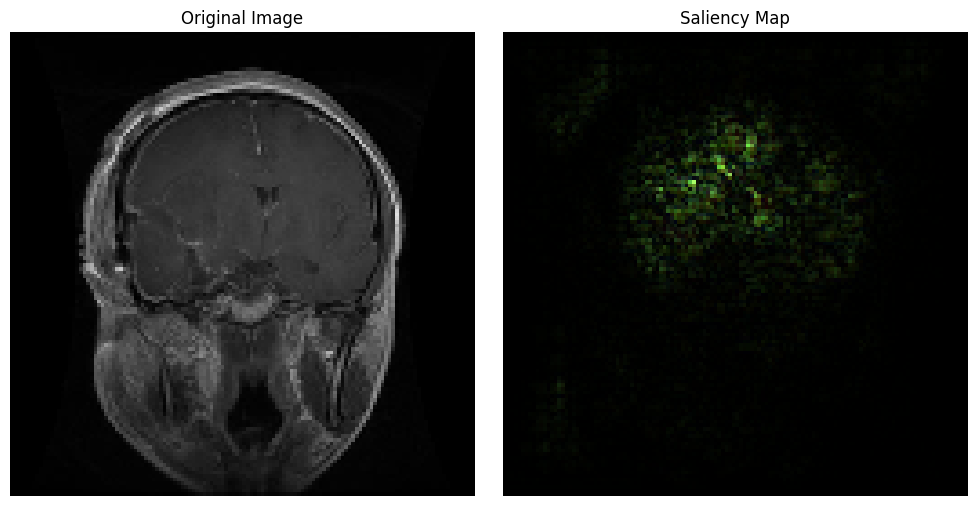

In [ ]:
# Visualization
image = images[0]
label = labels[0]
saliency_map_test = compute_saliency_map(model, image, label)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)  # Display the original image
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(saliency_map_test))
plt.title('Saliency Map')
plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
ig_ablation, ig_results = run_integrated_gradients_analysis(model, test_generator)

100%|██████████| 10/10 [00:11<00:00,  1.13s/it]


In [20]:
ig_heatmaps_full = np.sum(np.abs(ig_results), axis=-1)
ig_heatmaps_32 = ig_heatmaps_full[:32]

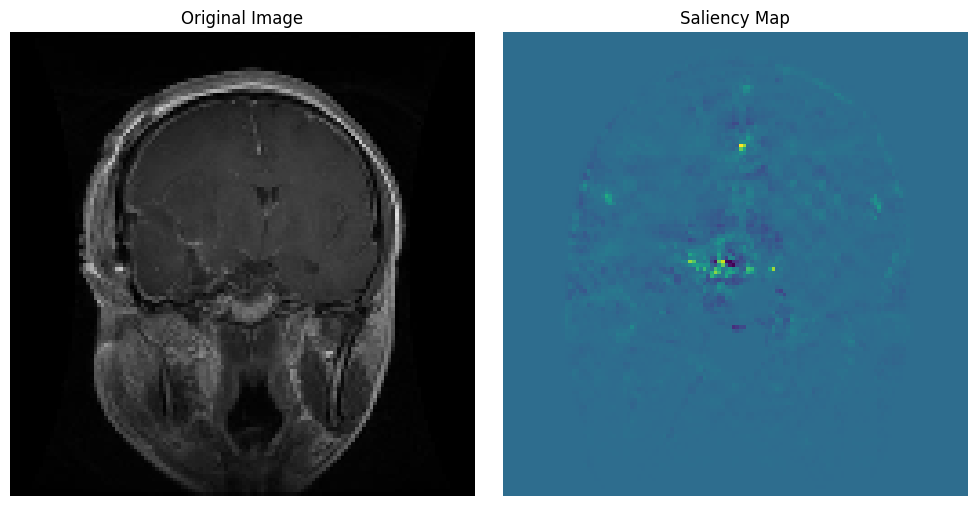

In [ ]:
# Visualization
ig_heatmap = np.sum(np.abs(ig_results[0]), axis=-1)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)  # Display the original image
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(tf.squeeze(ig_heatmap))
plt.title('Saliency Map')
plt.axis('off')

plt.tight_layout()
plt.show()

In [21]:
occlusion_results = run_rise_analysis(model, test_generator)

100%|██████████| 10/10 [14:56<00:00, 89.61s/it]


In [22]:
# Generate masks
input_size = (128, 128)
mask_size = 10
num_masks = 2000
masks = generate_masks(input_size, mask_size, num_masks)

# single: rise_map = calculate_importance_rise(model, images[0], masks), can use to plot histograms

In [23]:
rise_maps = []

for i in range (0, 32):
  rise_map = calculate_importance_rise(model, images[i], masks)
  rise_maps.append(rise_map)

rise_maps_32 = tf.stack(rise_maps)

In [27]:
def extract_single_channel(importance_map, channel_index):
    if channel_index < 0 or channel_index >= importance_map.shape[-1]:
        raise ValueError("Invalid channel index. Must be between 0 and {}.".format(importance_map.shape[-1] - 1))

    # Extract the specific channel
    channel_map = importance_map[:, :, channel_index]

    return channel_map

channel_index = 2
channel_map = extract_single_channel(rise_map, channel_index)

channel_map_np = channel_map.numpy()

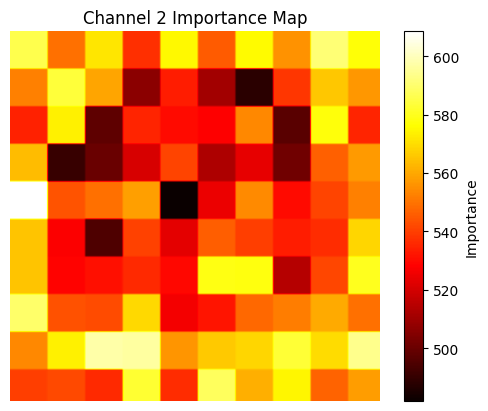

In [ ]:
plt.imshow(channel_map_np, cmap='hot')
plt.title(f'Channel {channel_index} Importance Map')
plt.colorbar(label='Importance')
plt.axis('off')
plt.show()

In [28]:
backprop_results = run_guided_backprop_analysis(model, test_generator)

  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━

 10%|█         | 1/10 [00:35<05:15, 35.09s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━

 20%|██        | 2/10 [01:00<03:57, 29.68s/it]

...

 80%|████████  | 8/10 [03:37<00:53, 26.55s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━

 90%|█████████ | 9/10 [04:03<00:26, 26.51s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━

100%|██████████| 10/10 [04:31<00:00, 27.16s/it]


In [29]:
guided_grads = compute_guided_backprop(model, images, labels)
guided_backprop_maps = tf.squeeze(guided_grads)  # Remove batch dimension and squeeze extra dimensions

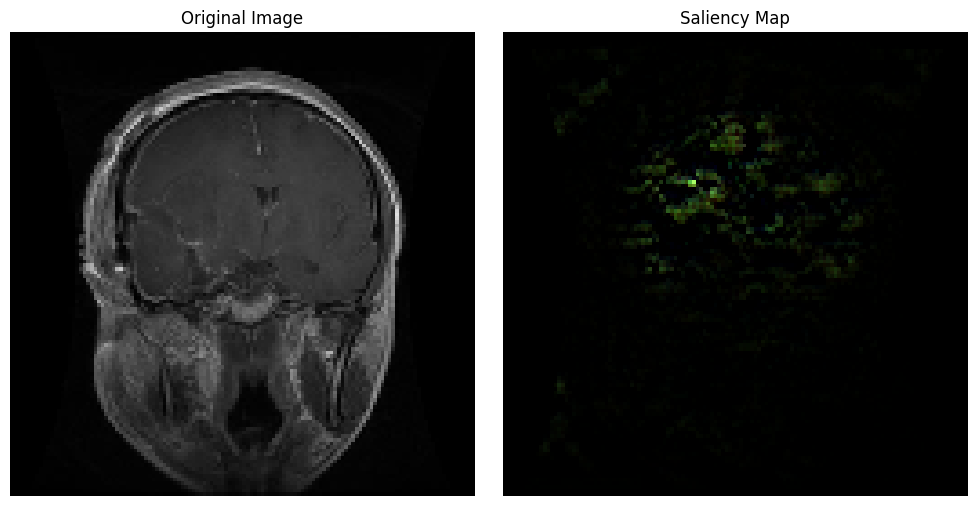

In [ ]:
# Visualization
guided_grad = compute_guided_backprop(model, image, label)
guided_backprop_map = tf.squeeze(guided_grad)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image)  # Display the original image
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(guided_backprop_map)
plt.title('Saliency Map')
plt.axis('off')

plt.tight_layout()
plt.show()

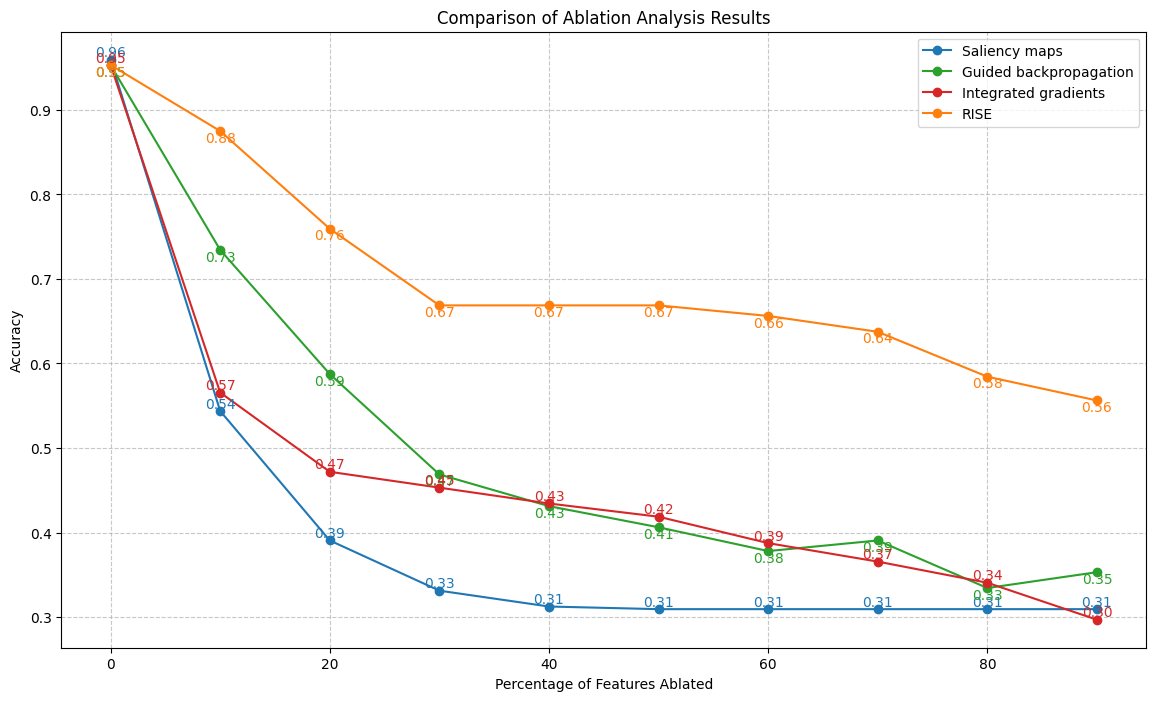

In [30]:
plot_ablation_results(saliency_results, backprop_results, ig_ablation, occlusion_results)

# New method

In [31]:
saliency_arrays = np.array(saliency_maps)
guided_backprop_arrays = np.array(guided_backprop_maps)
rise_arrays = np.array(rise_maps_32)
ig_arrays = ig_heatmaps_32

In [32]:
ig_final_arrays = []

for map in ig_arrays:
  map = np.repeat(map[:, :, np.newaxis], 3, axis=2)
  ig_final_arrays.append(map)

In [33]:
ig_final_arrays = np.array(ig_final_arrays)
print(ig_final_arrays.shape)

(32, 128, 128, 3)


In [34]:
rise_reshape = rise_maps_32[:, :, :, :3]
rise_arrays = np.array(rise_reshape)
rise_arrays.shape

(32, 128, 128, 3)

In [35]:
print(saliency_maps.shape,guided_backprop_maps.shape,ig_final_arrays.shape,rise_arrays.shape)

(32, 128, 128, 3) (32, 128, 128, 3) (32, 128, 128, 3) (32, 128, 128, 3)


In [36]:
print(type(saliency_arrays),type(guided_backprop_arrays),type(ig_arrays),type(rise_arrays))

<class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [37]:
def compute_batch_pixel_similarity_metrics(batch_importance_maps):
    """
    Compute pairwise similarity metrics for a batch of importance maps.

    Parameters:
    -----------
    batch_importance_maps : dict
        A dictionary where keys are method names and values are lists/arrays
        of importance maps for each image in the batch

    Returns:
    --------
    pd.DataFrame
        A dataframe containing pairwise metrics for each image
    """
    if not batch_importance_maps:
        raise ValueError("Input dictionary is empty")

    methods = list(batch_importance_maps.keys())
    batch_size = len(next(iter(batch_importance_maps.values())))

    # Validate batch consistency
    for method, maps in batch_importance_maps.items():
        if len(maps) != batch_size:
            raise ValueError(f"Inconsistent batch size for method {method}")

    all_image_results = []

    for img_idx in range(batch_size):
        # extract importance maps for image
        importance_maps = {
            method: maps[img_idx] for method, maps in batch_importance_maps.items()
        }

        # normalize/rank
        ranked_maps = []
        for k in importance_maps:
            map_array = np.array(importance_maps[k])

            if map_array.ndim == 3 and map_array.shape[2] == 3:
                map_array = np.mean(map_array, axis=2)

            ranked_map = stats.rankdata(map_array.flatten()).reshape(map_array.shape)
            ranked_maps.append(ranked_map)

        maps_array = np.array(ranked_maps)
        n_methods = len(methods)

        # Compute pairwise metrics
        image_results = []
        for i in range(n_methods):
            for j in range(i + 1, n_methods):
                rank_corr = stats.spearmanr(
                    maps_array[i].flatten(), maps_array[j].flatten()
                )[0]

                kendall_corr = stats.kendalltau(
                    maps_array[i].flatten(), maps_array[j].flatten()
                )[0]

                ndcg_scr = ndcg_score(
                    [maps_array[i].flatten()], [maps_array[j].flatten()]
                )

                image_results.append({
                    'Image Index': img_idx,
                    'Method1': methods[i],
                    'Method2': methods[j],
                    'Rank Correlation': rank_corr,
                    'Kendall\'s Tau': kendall_corr,
                    'NDCG Score': ndcg_scr
                })

        all_image_results.extend(image_results)

    return pd.DataFrame(all_image_results)

batch_maps = {
    'integrated_gradients': ig_final_arrays,
    'saliency': saliency_arrays,
    'guided_backpropagation': guided_backprop_arrays,
    'rise': rise_arrays
}

results_df = compute_batch_pixel_similarity_metrics(batch_maps)
results_df.to_csv('smc.csv')

In [38]:
averages = results_df.groupby(['Method1', 'Method2']).mean().reset_index()
averages = averages.drop(columns=['Image Index'])
averages.head(6)

,Method1,Method2,Rank Correlation,Kendall's Tau,NDCG Score
0,guided_backpropagation,rise,-0.017130,-0.012136,0.939240
1,integrated_gradients,guided_backpropagation,0.001239,0.001215,0.935829
2,integrated_gradients,rise,-0.002122,-0.001113,0.935132
3,integrated_gradients,saliency,-0.002791,-0.001475,0.935531
4,saliency,guided_backpropagation,0.376276,0.338926,0.977997
5,saliency,rise,-0.025133,-0.016391,0.940038
